# 02 - Metric Driver Slices

This notebook recreates the simplest plots behind `docs/reports/metric_analysis/metric_analysis.qmd` and `docs/reports/metric_analysis/thorough/metric_analysis.tex`.
Each slice varies one Class 1 assumption while Class 2 stays fixed at baseline.

Use this to understand how to create new one-parameter sensitivity checks without editing the production figure generator.

In [12]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable

def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "configs" / "baseline.yaml").exists() and (
            candidate / "simulation" / "config_loader.py"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook location.")

REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import result_metrics_from_result
from analysis.plot_style import BASELINE_COLOR, plot_driver_line
from simulation.config_loader import load_config
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import ThresholdRule

BASE_CONFIG = load_config(REPO_DIR / "configs" / "baseline.yaml")
pd.options.display.max_columns = 120


## Shared Values

Keep the setup light. The scenario changes below are written inline so it is clear which Class 1 assumption changes and what stays fixed.

In [13]:
SEEDS = [2027, 2028, 2029]


## Balking Step Slice

Class 1 changes, Class 2 stays fixed. This is intentionally written out instead of hidden behind one-line config-builder functions.

Balking step values:   0%|          | 0/11 [00:00<?, ?it/s]

,class_1_balk_step,seed,average_utilization,overall_percent_serviced,mean_accepted_booking_delay,mean_offered_booking_delay,class_1_percent_serviced,class_2_percent_serviced,overall_balking_rate,class_1_balking_rate,class_2_balking_rate,class_1_slot_utilization,class_2_slot_utilization,class_1_mean_offered_booking_delay,class_2_mean_offered_booking_delay,access_advantage_class_1,balking_rate_gap_class_1,delay_advantage_class_1
0,0.0,2028.0,0.840611,0.268647,9.450635,9.947912,0.296713,0.240343,0.161892,0.000000,0.325668,0.464669,0.373202,9.952853,9.942910,0.056370,-0.325668,-0.009944
1,0.1,2028.0,0.839555,0.267716,9.444310,10.073234,0.290476,0.245053,0.205243,0.069583,0.339594,0.453139,0.383818,10.060305,10.086097,0.045424,-0.270011,0.025792
2,0.2,2028.0,0.840439,0.267837,9.416928,10.156816,0.288550,0.247141,0.242223,0.138439,0.345963,0.451370,0.386787,10.169007,10.144562,0.041409,-0.207524,-0.024445
3,0.3,2028.0,0.840040,0.267414,9.327782,10.180079,0.281705,0.253057,0.281654,0.211891,0.351711,0.443065,0.395919,10.189414,10.170617,0.028648,-0.139820,-0.018797
4,0.4,2028.0,0.841210,0.267991,9.029017,9.966261,0.274405,0.261628,0.318291,0.284635,0.351612,0.427312,0.411330,9.961778,9.970823,0.012777,-0.066977,0.009045
5,0.5,2028.0,0.839098,0.268552,8.345978,9.295180,0.269121,0.267988,0.355920,0.356924,0.354921,0.417808,0.419806,9.293763,9.296547,0.001133,0.002003,0.002784
6,0.6,2028.0,0.841438,0.269283,7.812404,8.771013,0.259178,0.279327,0.386540,0.421659,0.351631,0.403567,0.437300,8.772154,8.769770,-0.020149,0.070028,-0.002384
7,0.7,2028.0,0.840639,0.268593,7.563060,8.556024,0.246705,0.290216,0.397010,0.467401,0.327490,0.383904,0.457220,8.569644,8.542585,-0.043511,0.139911,-0.027059
8,0.8,2028.0,0.840154,0.267474,7.445321,8.484993,0.242714,0.292083,0.406113,0.497864,0.314925,0.379823,0.459932,8.478993,8.490839,-0.049369,0.182939,0.011846
9,0.9,2028.0,0.838813,0.268837,7.367432,8.436175,0.238078,0.299699,0.405915,0.520417,0.291006,0.372203,0.466895,8.429990,8.442396,-0.061620,0.229412,0.012406


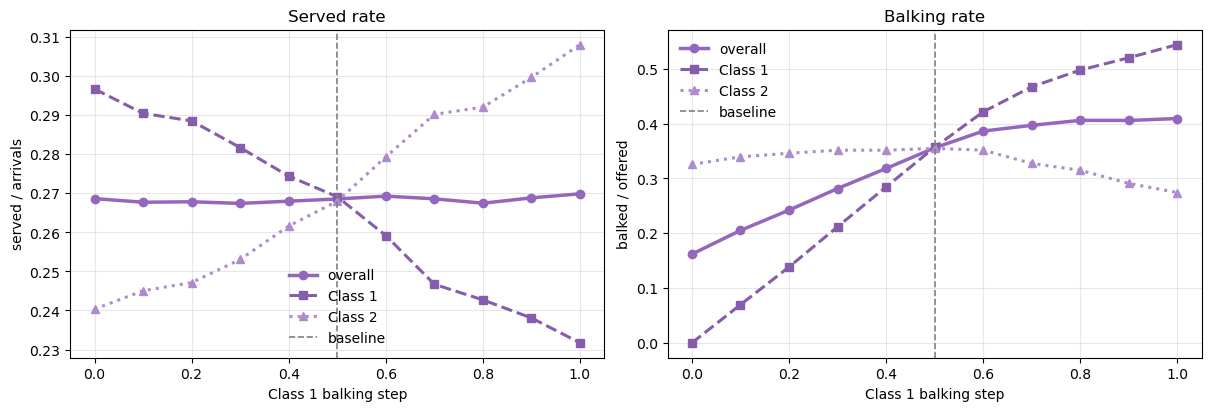

In [14]:
balk_step_values = np.linspace(0.0, 1.0, 11)
base_balk_rule = BASE_CONFIG.classes[1].balk_prob
baseline_balk_step = base_balk_rule.high - base_balk_rule.low

rows = []
for step in tqdm(balk_step_values, desc="Balking step values"):
    for seed in SEEDS:
        class_1_balk_rule = ThresholdRule(
            threshold=base_balk_rule.threshold,
            low=base_balk_rule.low,
            high=min(base_balk_rule.low + float(step), 1.0),
        )
        class_1_params = replace(BASE_CONFIG.classes[1], balk_prob=class_1_balk_rule)
        config = replace(
            BASE_CONFIG,
            classes={**BASE_CONFIG.classes, 1: class_1_params},
            seed=seed,
        )
        result = ClinicAppointmentSimulation(config).run()
        rows.append({"class_1_balk_step": step, "seed": seed, **result_metrics_from_result(result)})

balk_step_df = (
    pd.DataFrame(rows)
    .groupby("class_1_balk_step", as_index=False)
    .mean(numeric_only=True)
)
display(balk_step_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

served_series = [
    ("overall_percent_serviced", "overall"),
    ("class_1_percent_serviced", "Class 1"),
    ("class_2_percent_serviced", "Class 2"),
]
for index, (metric, label) in enumerate(served_series):
    plot_driver_line(axes[0], balk_step_df["class_1_balk_step"], balk_step_df[metric], label, driver="balking", index=index)
axes[0].axvline(baseline_balk_step, color=BASELINE_COLOR, linestyle="--", linewidth=1.2, label="baseline")
axes[0].set_title("Served rate")
axes[0].set_xlabel("Class 1 balking step")
axes[0].set_ylabel("served / arrivals")
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False)

balking_series = [
    ("overall_balking_rate", "overall"),
    ("class_1_balking_rate", "Class 1"),
    ("class_2_balking_rate", "Class 2"),
]
for index, (metric, label) in enumerate(balking_series):
    plot_driver_line(axes[1], balk_step_df["class_1_balk_step"], balk_step_df[metric], label, driver="balking", index=index)
axes[1].axvline(baseline_balk_step, color=BASELINE_COLOR, linestyle="--", linewidth=1.2, label="baseline")
axes[1].set_title("Balking rate")
axes[1].set_xlabel("Class 1 balking step")
axes[1].set_ylabel("balked / offered")
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False)

plt.show()


## Compare Multiple Drivers

This compact table uses the same inline style for each driver. Add a new block in the `if`/`elif` chain when exploring a new one-parameter slice.

In [15]:
driver_specs = [
    {"name": "balking_step", "values": np.linspace(0.0, 1.0, 11)},
    {"name": "balking_threshold", "values": list(range(0, BASE_CONFIG.horizon_days, 2))},
    {"name": "no_show_step", "values": np.linspace(0.0, 1.0, 11)},
    {"name": "cancel_prob", "values": np.linspace(0.0, 0.30, 11)},
    {"name": "arrival_multiplier", "values": np.linspace(0.5, 1.5, 11)},
]

summary_rows = []
for spec in tqdm(driver_specs, desc="Driver slices"):
    name = spec["name"]
    rows = []

    for value in tqdm(spec["values"], desc=name, leave=False):
        for seed in SEEDS:
            classes = dict(BASE_CONFIG.classes)

            if name == "balking_step":
                rule = BASE_CONFIG.classes[1].balk_prob
                classes[1] = replace(
                    classes[1],
                    balk_prob=ThresholdRule(threshold=rule.threshold, low=rule.low, high=min(rule.low + float(value), 1.0)),
                )
            elif name == "balking_threshold":
                rule = BASE_CONFIG.classes[1].balk_prob
                classes[1] = replace(
                    classes[1],
                    balk_prob=ThresholdRule(threshold=int(value), low=rule.low, high=rule.high),
                )
            elif name == "no_show_step":
                rule = BASE_CONFIG.classes[1].no_show_prob
                classes[1] = replace(
                    classes[1],
                    no_show_prob=ThresholdRule(threshold=rule.threshold, low=rule.low, high=min(rule.low + float(value), 1.0)),
                )
            elif name == "cancel_prob":
                classes[1] = replace(classes[1], cancel_prob=float(value))
            elif name == "arrival_multiplier":
                classes = {
                    class_id: replace(params, lambda_per_day=params.lambda_per_day * float(value))
                    for class_id, params in BASE_CONFIG.classes.items()
                }

            config = replace(BASE_CONFIG, classes=classes, seed=seed)
            result = ClinicAppointmentSimulation(config).run()
            rows.append({name: value, "seed": seed, **result_metrics_from_result(result)})

    df = pd.DataFrame(rows).groupby(name, as_index=False).mean(numeric_only=True)
    first = df.iloc[0]
    last = df.iloc[-1]
    summary_rows.append(
        {
            "driver": name,
            "x_start": first[name],
            "x_end": last[name],
            "delta_utilization": last.average_utilization - first.average_utilization,
            "delta_access": last.overall_percent_serviced - first.overall_percent_serviced,
            "delta_offered_wait": last.mean_offered_booking_delay - first.mean_offered_booking_delay,
            "delta_class_gap": last.access_advantage_class_1 - first.access_advantage_class_1,
        }
    )

pd.DataFrame(summary_rows).sort_values("delta_access")


Driver slices:   0%|          | 0/5 [00:00<?, ?it/s]

balking_step:   0%|          | 0/11 [00:00<?, ?it/s]

balking_threshold:   0%|          | 0/7 [00:00<?, ?it/s]

no_show_step:   0%|          | 0/11 [00:00<?, ?it/s]

cancel_prob:   0%|          | 0/11 [00:00<?, ?it/s]

arrival_multiplier:   0%|          | 0/11 [00:00<?, ?it/s]

,driver,x_start,x_end,delta_utilization,delta_access,delta_offered_wait,delta_class_gap
4,arrival_multiplier,0.5,1.5,-0.063613,-0.396299,5.104292,0.002248
2,no_show_step,0.0,1.0,-0.269549,-0.086086,0.000000,-0.172946
1,balking_threshold,0.0,12.0,-0.003653,-0.000383,2.143694,0.158250
0,balking_step,0.0,1.0,0.000713,0.001231,-1.557015,-0.132739
3,cancel_prob,0.0,0.3,0.132620,0.043090,-4.327552,-0.427903


## Optional Widget Explorer

`ipywidgets` needs a callable, so this is the one place where a function is useful. The config changes still stay explicit inside the function.

In [16]:
def run_one_point(class1_balk_step=0.50, class1_threshold=9, class1_cancel=0.10, arrival_multiplier=1.0, seed=2027):
    base_rule = BASE_CONFIG.classes[1].balk_prob
    class_1_balk_rule = ThresholdRule(
        threshold=int(class1_threshold),
        low=base_rule.low,
        high=min(base_rule.low + float(class1_balk_step), 1.0),
    )

    multiplier = float(arrival_multiplier)
    class_1_params = replace(
        BASE_CONFIG.classes[1],
        balk_prob=class_1_balk_rule,
        cancel_prob=float(class1_cancel),
        lambda_per_day=BASE_CONFIG.classes[1].lambda_per_day * multiplier,
    )
    class_2_params = replace(
        BASE_CONFIG.classes[2],
        lambda_per_day=BASE_CONFIG.classes[2].lambda_per_day * multiplier,
    )
    config = replace(BASE_CONFIG, classes={1: class_1_params, 2: class_2_params}, seed=int(seed))
    result = ClinicAppointmentSimulation(config).run()
    return pd.Series(result_metrics_from_result(result)).to_frame("value")

try:
    import ipywidgets as widgets
    from IPython.display import display

    explorer = widgets.interactive(
        run_one_point,
        class1_balk_step=(0.0, 1.0, 0.05),
        class1_threshold=(0, BASE_CONFIG.horizon_days - 1, 1),
        class1_cancel=(0.0, 0.30, 0.01),
        arrival_multiplier=(0.5, 1.5, 0.05),
        seed=(1, 5000, 1),
    )
    display(explorer)
except ImportError:
    display(run_one_point())


interactive(children=(FloatSlider(value=0.5, description='class1_balk_step', max=1.0, step=0.05), IntSlider(va…